# Kafka broker transient experiment plots

This notebook plots the CSV results produced by `com.myexam.kafka.App`. It covers:

- baseline queue behaviour;
- the effect of `BatchSize` on gateway and service backlog;
- the effect of `Timeout` on gateway and service backlog; and
- cumulative batching-induced idle behaviour.

Run the Java experiments from the project root before running this notebook.

## 1. Generate the outcome CSV files

From the project root:

```bash
mvn org.codehaus.mojo:exec-maven-plugin:3.5.0:java \
  -Dexec.mainClass=com.myexam.kafka.App
```

The command creates or replaces the required files in `outcomes/`.


In [1]:
!git clone https://github.com/YUEXIN7/kafka-message-broker-qesm.git

Cloning into 'kafka-message-broker-qesm'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 88 (delta 14), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 729.50 KiB | 3.36 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [2]:
%cd kafka-message-broker-qesm

/content/kafka-message-broker-qesm


In [3]:
!ls outcomes/

baseline_queue_behaviour.csv  batch_size_30_backlog.csv
batching_induced_idle.csv     timeout_12_5_backlog.csv
batch_size_10_backlog.csv     timeout_35_backlog.csv


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.title_fontsize": 10,
    "legend.fontsize": 9,
})

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "pom.xml").exists():
            return candidate
    raise FileNotFoundError("Could not find the project folder containing pom.xml")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTCOMES_DIR = PROJECT_ROOT / "outcomes"

OUTCOME_FILES = {
    "baseline": "baseline_queue_behaviour.csv",
    "batch_size_10": "batch_size_10_backlog.csv",
    "batch_size_30": "batch_size_30_backlog.csv",
    "timeout_12_5": "timeout_12_5_backlog.csv",
    "timeout_35": "timeout_35_backlog.csv",
    "batching_idle": "batching_induced_idle.csv",
}

def finish_plot(fig):
    fig.tight_layout()
    plt.show()

## 2. Load and validate the results

In [5]:
missing_files = [
    OUTCOMES_DIR / filename
    for filename in OUTCOME_FILES.values()
    if not (OUTCOMES_DIR / filename).is_file()
]
if missing_files:
    missing = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing experiment results. Run com.myexam.app.qesm.App first:\n" + missing
    )

results = {
    name: pd.read_csv(OUTCOMES_DIR / filename)
    for name, filename in OUTCOME_FILES.items()
}

normal_columns = {"time", "meanMsgsAtGateway", "meanAtService"}
idle_columns = {
    "time",
    "cumulativeEmpty",
    "cumulativeBatchingIdleReward",
    "batchingIdleTime",
    "batchingIdleFraction",
}

for name, frame in results.items():
    required = idle_columns if name == "batching_idle" else normal_columns
    missing_columns = required.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"{OUTCOME_FILES[name]} is missing columns: {sorted(missing_columns)}")
    if frame.empty:
        raise ValueError(f"{OUTCOME_FILES[name]} contains no data rows")
    if not frame["time"].is_monotonic_increasing:
        raise ValueError(f"Time is not ordered in {OUTCOME_FILES[name]}")

summary = pd.DataFrame([
    {
        "experiment": name,
        "rows": len(frame),
        "start_time": frame["time"].iloc[0],
        "end_time": frame["time"].iloc[-1],
    }
    for name, frame in results.items()
])
display(summary)

,experiment,rows,start_time,end_time
0,baseline,2501,0.0,250.0
1,batch_size_10,2501,0.0,250.0
2,batch_size_30,2501,0.0,250.0
3,timeout_12_5,2501,0.0,250.0
4,timeout_35,2501,0.0,250.0
5,batching_idle,2501,0.0,250.0


## 3. Baseline queue behaviour

Baseline parameters: `BatchSize=20`, `Timeout=25`, `Overhead=2`, and `Stability=30`.

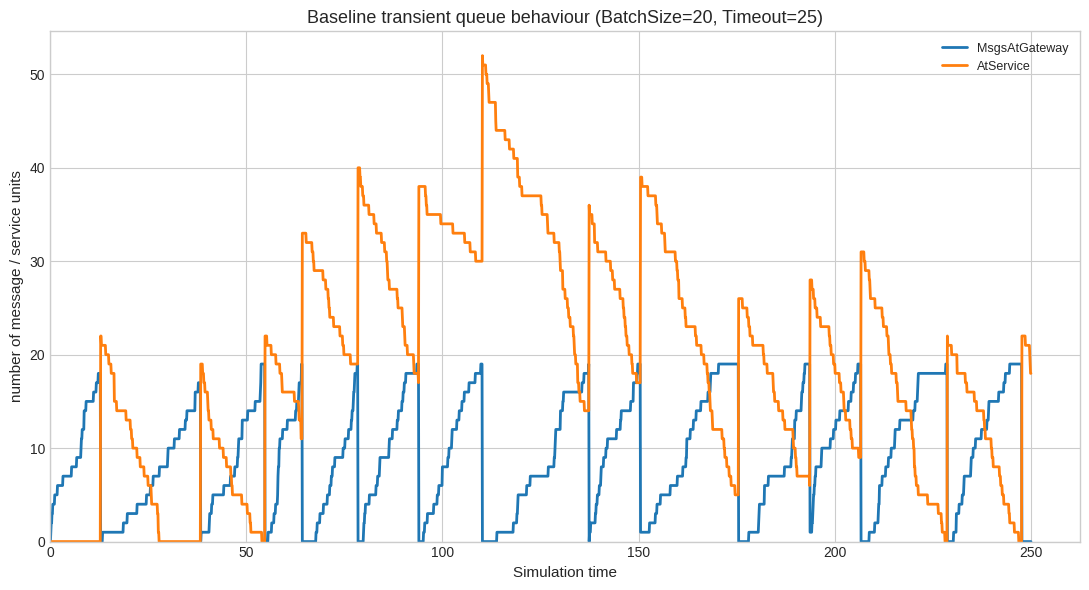

In [39]:
baseline = results["baseline"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(baseline["time"], baseline["meanMsgsAtGateway"], label="MsgsAtGateway", linewidth=2)
ax.plot(baseline["time"], baseline["meanAtService"], label="AtService", linewidth=2)
ax.set_title("Baseline transient queue behaviour (BatchSize=20, Timeout=25)")
ax.set_xlabel("Simulation time")
ax.set_ylabel("number of message / service units")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend()
finish_plot(fig)

## 4. BatchSize effect on backlog

This comparison changes only `BatchSize`. The baseline result supplies the `BatchSize=20` series.

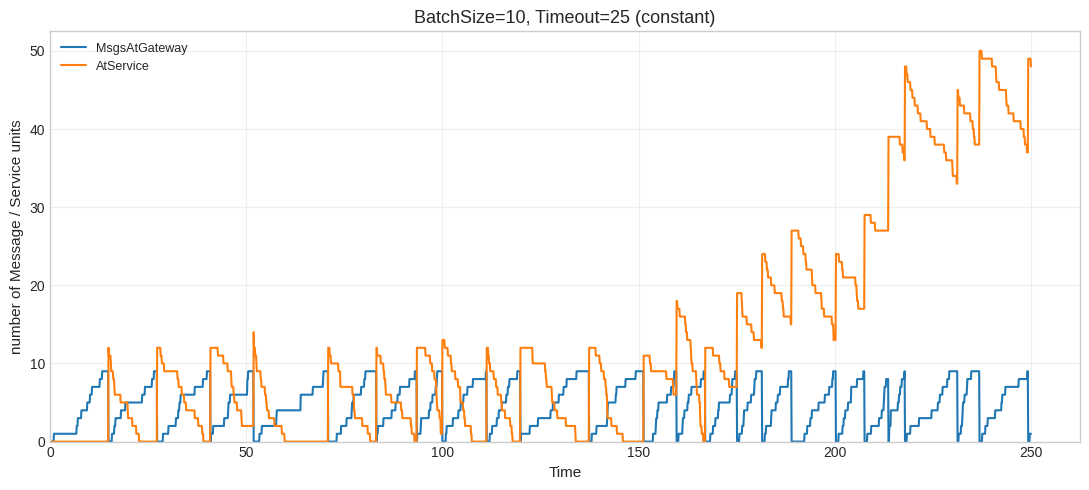

In [40]:
frame = results["batch_size_10"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService"
)

ax.set_title("BatchSize=10, Timeout=25 (constant)")
ax.set_xlabel("Time")
ax.set_ylabel("number of Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

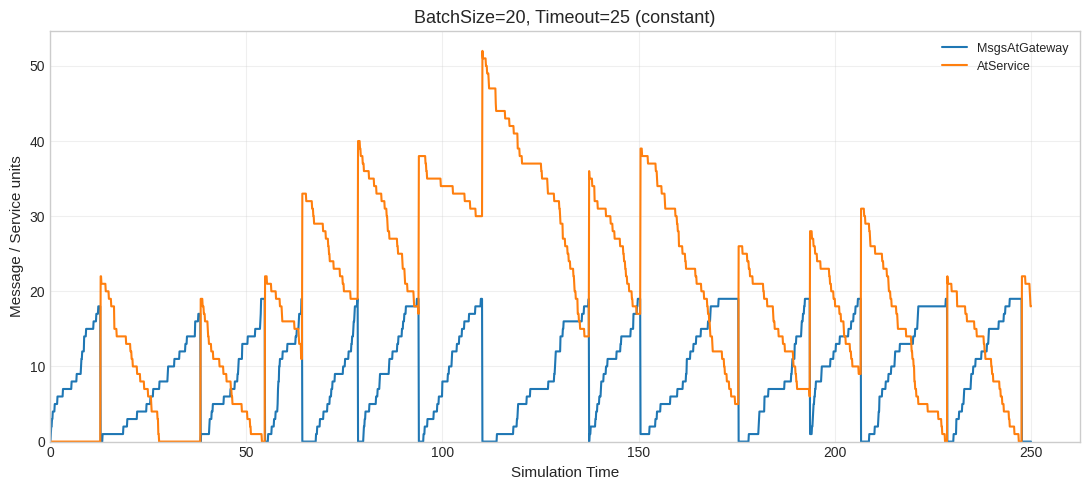

In [41]:
frame = results["baseline"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService"
)

ax.set_title("BatchSize=20, Timeout=25 (constant)")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

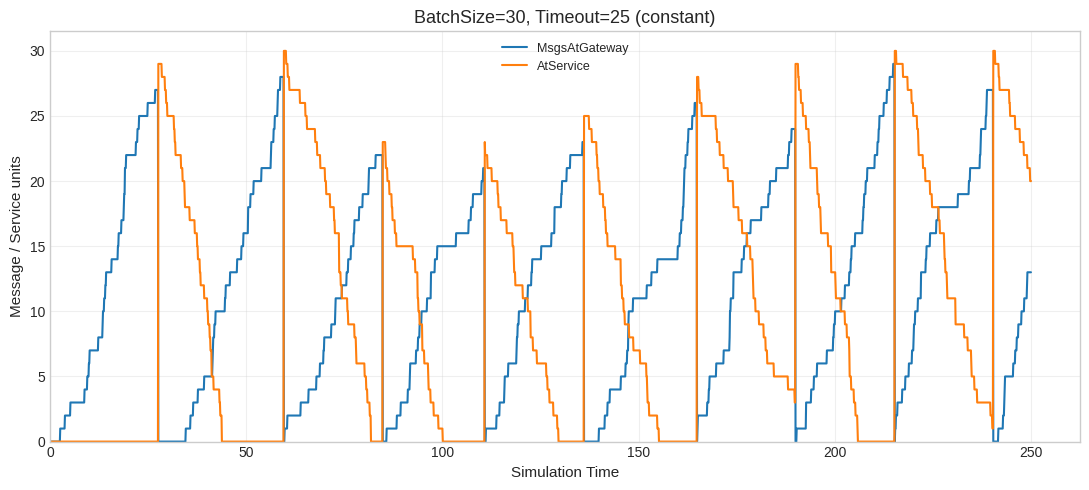

In [42]:
frame = results["batch_size_30"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService"
)

ax.set_title("BatchSize=30, Timeout=25 (constant)")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

## 5. Timeout effect on backlog

This comparison changes only `Timeout`. The baseline result supplies the `Timeout=25` series.

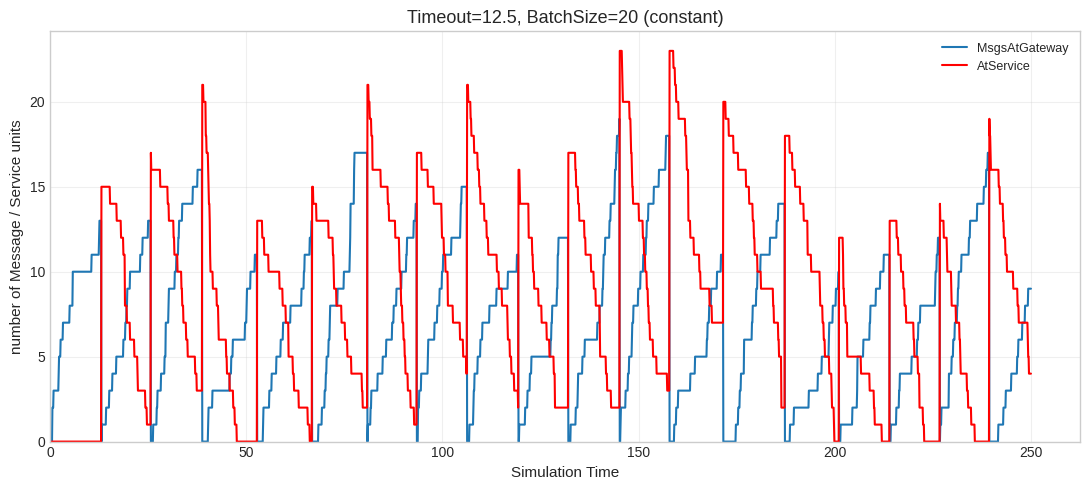

In [43]:
frame = results["timeout_12_5"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService",
    color="red"
)

ax.set_title("Timeout=12.5, BatchSize=20 (constant)")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("number of Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

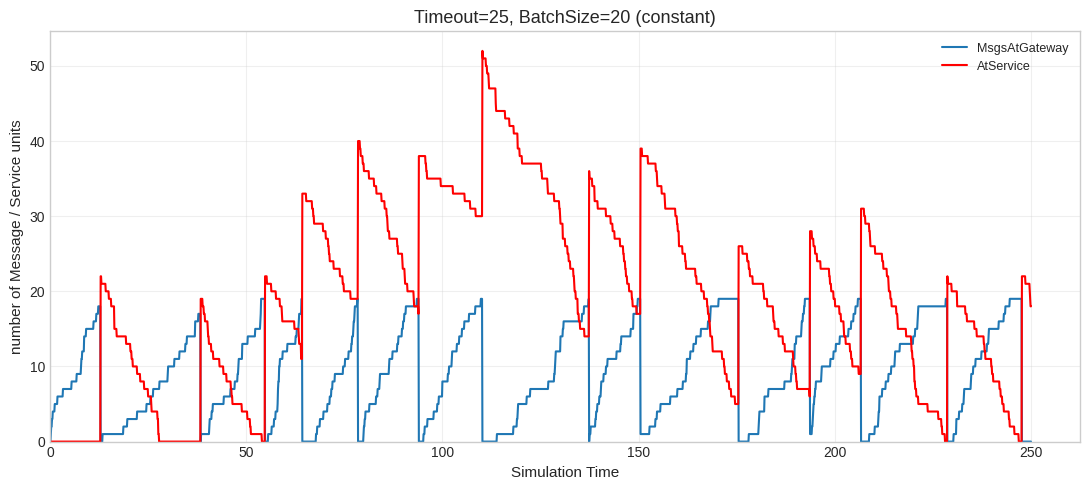

In [44]:
frame = results["baseline"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService",
    color="red"
)

ax.set_title("Timeout=25, BatchSize=20 (constant)")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("number of Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

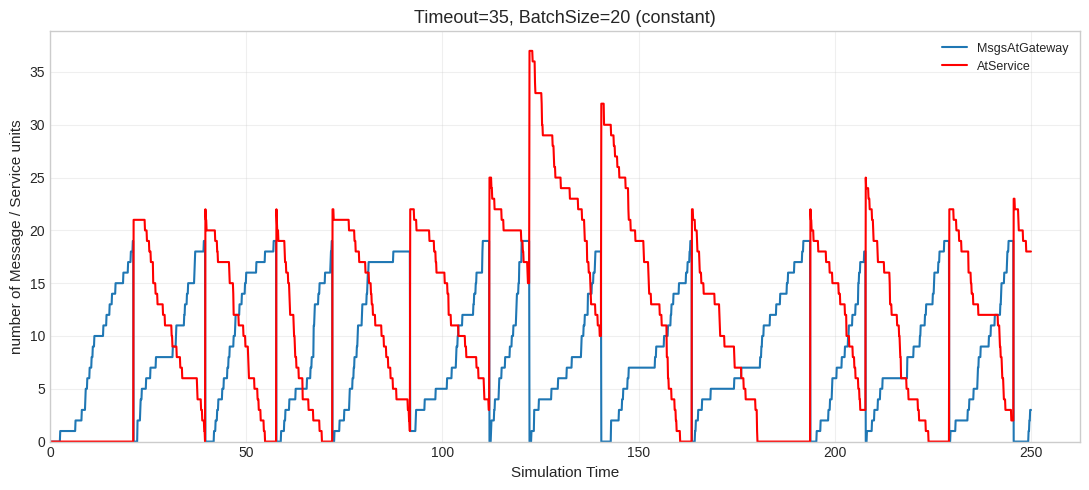

In [45]:
frame = results["timeout_35"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame["time"],
    frame["meanMsgsAtGateway"],
    label="MsgsAtGateway"
)

ax.plot(
    frame["time"],
    frame["meanAtService"],
    label="AtService",
    color="red"
)

ax.set_title("Timeout=35, BatchSize=20 (constant)")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("number of Message / Service units")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

## 6. Batching-induced idle study

This study uses the cumulative watcher rewards `Empty;If(Idle==1&&NotEmpty==1,2,0)`. The watcher reward is divided by two by the Java analysis to obtain `batchingIdleTime`.

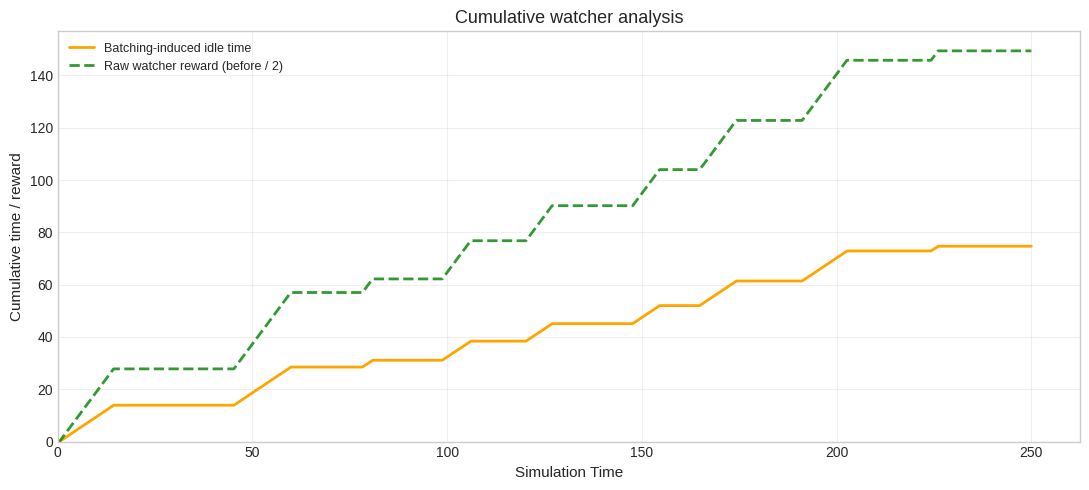

In [46]:
idle = results["batching_idle"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    idle["time"],
    idle["batchingIdleTime"],
    label="Batching-induced idle time",
    color="orange",
    linewidth=2
)

ax.plot(
    idle["time"],
    idle["cumulativeBatchingIdleReward"],
    label="Raw watcher reward (before / 2)",
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.8
)

ax.set_title("Cumulative watcher analysis")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("Cumulative time / reward")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)

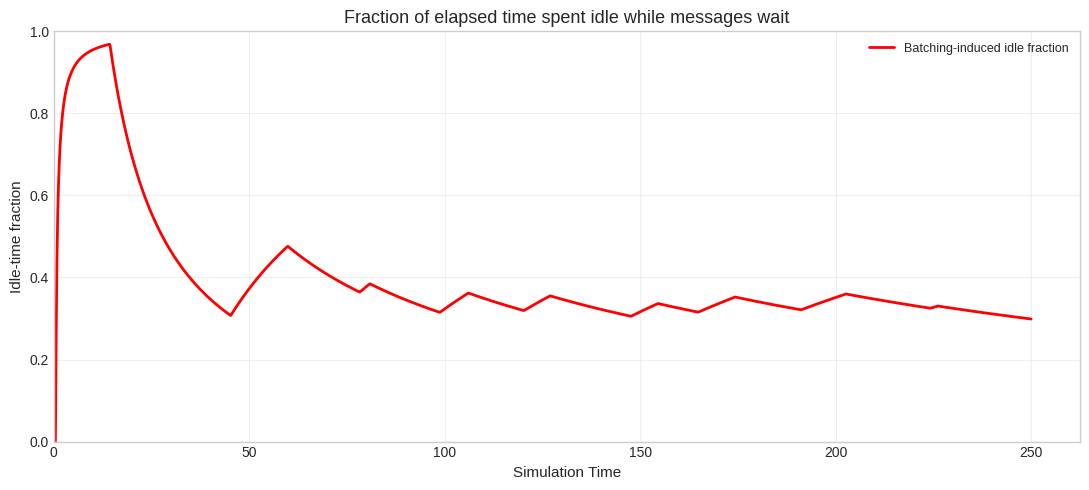

In [47]:
idle = results["batching_idle"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    idle["time"],
    idle["batchingIdleFraction"],
    label="Batching-induced idle fraction",
    color="red",
    linewidth=2
)

ax.set_title("Fraction of elapsed time spent idle while messages wait")
ax.set_xlabel("Simulation Time")
ax.set_ylabel("Idle-time fraction")

ax.set_xlim(left=0)
ax.set_ylim(0, 1)

ax.legend()
ax.grid(True, alpha=0.3)

finish_plot(fig)